# 📊 Superstore Sales Data — Comprehensive Exploratory Data Analysis

**Project task —EDA & Hypothesis Testing**  
**Dataset:** SuperStore_Orders.csv (51,290 records · 21 features)  
**Period Covered:** 2011 – 2014  
**Author:** Superstore Sales Data Analysis Project  

---

### Notebook Structure
1. Library Imports & Global Settings  
2. Data Loading & Initial Inspection  
3. Data Cleaning  
4. Summary Statistics  
5. Sales by Product Category & Sub-Category  
6. Sales by Region & Customer Segment  
7. Sales Trends Over Time  
8. Hypothesis Testing  
9. Key Business Insights Summary  

---
## 1. Library Imports & Global Settings

In [156]:
# ── Standard data science libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot aesthetics ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
    'figure.facecolor': 'white',
})

# ── Colour palettes used throughout ──────────────────────────────────────
CAT_COLORS  = ['#2E75B6', '#1A9E75', '#D4A017']         # 3 categories
SEG_COLORS  = ['#2E75B6', '#7B68C8', '#1A9E75']         # 3 segments
REG_PALETTE = 'Blues_d'
TIME_COLOR  = '#2E75B6'

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## 2. Data Loading & Initial Inspection

In [157]:
# ── Load dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('SuperStore_Orders.csv', encoding='latin1')

# Fix sales column: remove thousands-separator commas, cast to numeric
df['sales'] = pd.to_numeric(df['sales'].astype(str).str.replace(',', '', regex=False),
                             errors='coerce')

# Parse date columns — dataset has two mixed formats:
#   M/D/YYYY (e.g. 1/13/2011)  and  DD-MM-YYYY (e.g. 13-01-2011)
def parse_mixed_date(s):
    for fmt in ["%m/%d/%Y", "%d-%m-%Y", "%d/%m/%Y"]:
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    return pd.NaT

df["order_date"] = df["order_date"].apply(parse_mixed_date)
df["ship_date"]  = df["ship_date"].apply(parse_mixed_date)

print(f'Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range    : {df["order_date"].min().date()}  →  {df["order_date"].max().date()}')
print()
df.head(5)

Dataset shape : 51,290 rows × 21 columns
Date range    : 2011-01-01  →  2014-12-31



,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [158]:
# ── Column data types ─────────────────────────────────────────────────────
print('Column names and data types:')
print('─' * 40)
for col, dtype in df.dtypes.items():
    print(f'  {col:<20} {dtype}')

Column names and data types:
────────────────────────────────────────
  order_id             object
  order_date           datetime64[ns]
  ship_date            datetime64[ns]
  ship_mode            object
  customer_name        object
  segment              object
  state                object
  country              object
  market               object
  region               object
  product_id           object
  category             object
  sub_category         object
  product_name         object
  sales                int64
  quantity             int64
  discount             float64
  profit               float64
  shipping_cost        float64
  order_priority       object
  year                 int64


In [159]:
# ── Missing value audit ───────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values detected in any column.')
else:
    print('⚠️  Columns with missing values:')
    display(missing_df)

✅ No missing values detected in any column.


In [160]:
# ── Duplicate check ───────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'Duplicate rows  : {dupes}')
print(f'Unique orders   : {df["order_id"].nunique():,}')
print(f'Unique customers: {df["customer_name"].nunique():,}')
print(f'Unique products : {df["product_name"].nunique():,}')
print()
print('Unique values per categorical column:')
for col in ['category','sub_category','segment','region','market','ship_mode','order_priority']:
    print(f'  {col:<18}: {df[col].unique().tolist()}')

Duplicate rows  : 0
Unique orders   : 25,035
Unique customers: 795
Unique products : 3,788

Unique values per categorical column:
  category          : ['Office Supplies', 'Furniture', 'Technology']
  sub_category      : ['Storage', 'Supplies', 'Paper', 'Furnishings', 'Machines', 'Appliances', 'Copiers', 'Chairs', 'Tables', 'Bookcases', 'Phones', 'Accessories', 'Labels', 'Art', 'Envelopes', 'Fasteners', 'Binders']
  segment           : ['Consumer', 'Home Office', 'Corporate']
  region            : ['Africa', 'Oceania', 'EMEA', 'North', 'Canada', 'Southeast Asia', 'Central', 'South', 'Caribbean', 'North Asia', 'East', 'West', 'Central Asia']
  market            : ['Africa', 'APAC', 'EMEA', 'EU', 'Canada', 'LATAM', 'US']
  ship_mode         : ['Standard Class', 'Second Class', 'Same Day', 'First Class']
  order_priority    : ['Medium', 'High', 'Critical', 'Low']


---
## 3. Data Cleaning

In [161]:
#remove duplicate ordeers 
df= df.drop_duplicates(subset='order_id')
# ── Derive useful time columns ─────────────────────────────────────────────
df['order_year']       = df['order_date'].dt.year
df['order_month']      = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.strftime('%b')
df['order_quarter']    = df['order_date'].dt.quarter
df['year_month']       = df['order_date'].dt.to_period('M')

# Derive profit margin %
df['profit_margin_pct'] = np.where(
    df['sales'] > 0,
    (df['profit'] / df['sales'] * 100).round(2),
    0
)

print('✅ Derived columns added:')
print('   order_year, order_month, order_month_name, order_quarter, year_month, profit_margin_pct')
print(f'\nFinal clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Derived columns added:
   order_year, order_month, order_month_name, order_quarter, year_month, profit_margin_pct

Final clean dataset: 25,035 rows × 27 columns


---
## 4. Summary Statistics

We calculate descriptive statistics for the key numerical features: **Sales**, **Profit**, **Quantity**, **Discount**, and **Shipping Cost**.

In [162]:
# ── Descriptive statistics table ─────────────────────────────────────────
num_cols = ['sales', 'profit', 'quantity', 'discount', 'shipping_cost']
stats_df = df[num_cols].describe().T.round(2)
stats_df.columns = ['Count','Mean','Std Dev','Min','25%','Median','75%','Max']
stats_df.index = ['Sales ($)', 'Profit ($)', 'Quantity', 'Discount', 'Shipping Cost ($)']

print('=' * 80)
print('DESCRIPTIVE STATISTICS — KEY NUMERICAL FEATURES')
print('=' * 80)
display(stats_df)

DESCRIPTIVE STATISTICS — KEY NUMERICAL FEATURES


,Count,Mean,Std Dev,Min,25%,Median,75%,Max
Sales ($),25035.0,372.08,608.94,1.00,52.0,155.00,438.00,17500.00
Profit ($),25035.0,43.00,232.18,-6599.98,0.0,14.64,63.09,8399.98
Quantity,25035.0,3.80,2.41,1.00,2.0,3.00,5.00,14.00
Discount,25035.0,0.14,0.21,0.00,0.0,0.00,0.20,0.85
Shipping Cost ($),25035.0,41.43,74.98,0.00,4.8,15.09,44.22,933.57


In [163]:
# ── High-level KPIs ───────────────────────────────────────────────────────
total_sales    = df['sales'].sum()
total_profit   = df['profit'].sum()
total_orders   = df['order_id'].nunique()
avg_order_val  = total_sales / total_orders
overall_margin = (total_profit / total_sales * 100)

print('=' * 55)
print('   KEY PERFORMANCE INDICATORS (2011–2014)')
print('=' * 55)
print(f'  Total Sales          : ${total_sales:>12,.0f}')
print(f'  Total Profit         : ${total_profit:>12,.0f}')
print(f'  Total Orders         : {total_orders:>13,}')
print(f'  Avg Order Value      : ${avg_order_val:>12,.2f}')
print(f'  Overall Profit Margin: {overall_margin:>12.2f}%')
print('=' * 55)

   KEY PERFORMANCE INDICATORS (2011–2014)
  Total Sales          : $   9,315,105
  Total Profit         : $   1,076,543
  Total Orders         :        25,035
  Avg Order Value      : $      372.08
  Overall Profit Margin:        11.56%


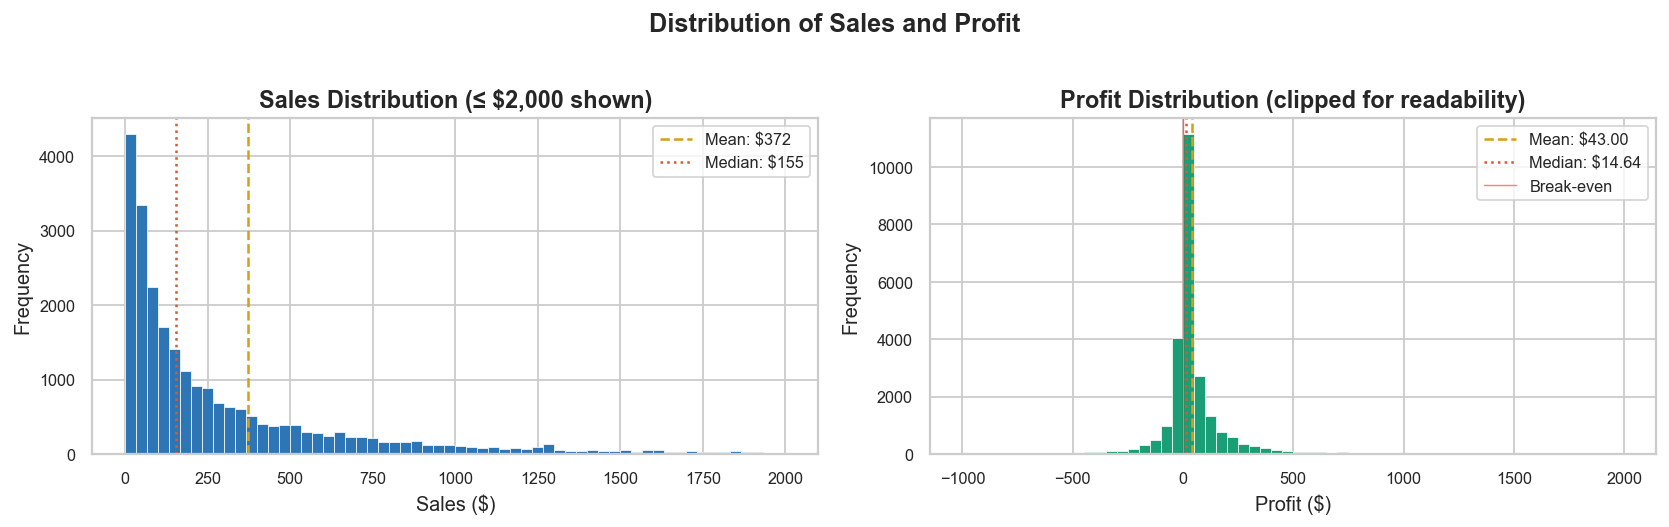


📌 Insight: Sales are heavily right-skewed — most orders are low-value, with a long tail of high-value orders.
📌 Insight: A notable share of orders yield negative profit, indicating the impact of heavy discounting.


In [164]:
# ── Distribution plots for Sales and Profit ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribution of Sales and Profit', fontsize=14, fontweight='bold', y=1.01)

# Sales distribution (cap at 2000 for readability)
sales_cap = df[df['sales'] <= 2000]['sales']
axes[0].hist(sales_cap, bins=60, color='#2E75B6', edgecolor='white', linewidth=0.4)
axes[0].set_title('Sales Distribution (≤ $2,000 shown)')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['sales'].mean(),   color='#D4A017', linestyle='--', linewidth=1.4, label=f'Mean: ${df["sales"].mean():,.0f}')
axes[0].axvline(df['sales'].median(), color='#D85A30', linestyle=':',  linewidth=1.4, label=f'Median: ${df["sales"].median():,.0f}')
axes[0].legend()

# Profit distribution (clip extreme outliers)
profit_clip = df[(df['profit'] >= -1000) & (df['profit'] <= 2000)]['profit']
axes[1].hist(profit_clip, bins=60, color='#1A9E75', edgecolor='white', linewidth=0.4)
axes[1].set_title('Profit Distribution (clipped for readability)')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['profit'].mean(),   color='#D4A017', linestyle='--', linewidth=1.4, label=f'Mean: ${df["profit"].mean():,.2f}')
axes[1].axvline(df['profit'].median(), color='#D85A30', linestyle=':',  linewidth=1.4, label=f'Median: ${df["profit"].median():,.2f}')
axes[1].axvline(0, color='red', linewidth=0.8, alpha=0.5, label='Break-even')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Sales are heavily right-skewed — most orders are low-value, with a long tail of high-value orders.')
print('📌 Insight: A notable share of orders yield negative profit, indicating the impact of heavy discounting.')

---
## 5. Sales by Product Category & Sub-Category

We group the data by **Category** and **Sub-Category** to identify which product segments drive the most revenue and profit.

In [165]:
# ── Category-level aggregation ────────────────────────────────────────────
cat_grp = (df.groupby('category')[['sales','profit']]
             .sum()
             .reset_index()
             .sort_values('sales', ascending=False))
cat_grp['profit_margin_pct'] = (cat_grp['profit'] / cat_grp['sales'] * 100).round(2)
cat_grp['sales_share_pct']   = (cat_grp['sales'] / cat_grp['sales'].sum() * 100).round(2)

print('Category Summary:')
display(cat_grp.rename(columns={
    'category':'Category', 'sales':'Total Sales ($)',
    'profit':'Total Profit ($)', 'profit_margin_pct':'Profit Margin (%)',
    'sales_share_pct':'Sales Share (%)'
}))

Category Summary:


,Category,Total Sales ($),Total Profit ($),Profit Margin (%),Sales Share (%)
2,Technology,3666791,533994.3952,14.56,39.36
0,Furniture,3215999,214713.8195,6.68,34.52
1,Office Supplies,2432315,327835.2511,13.48,26.11


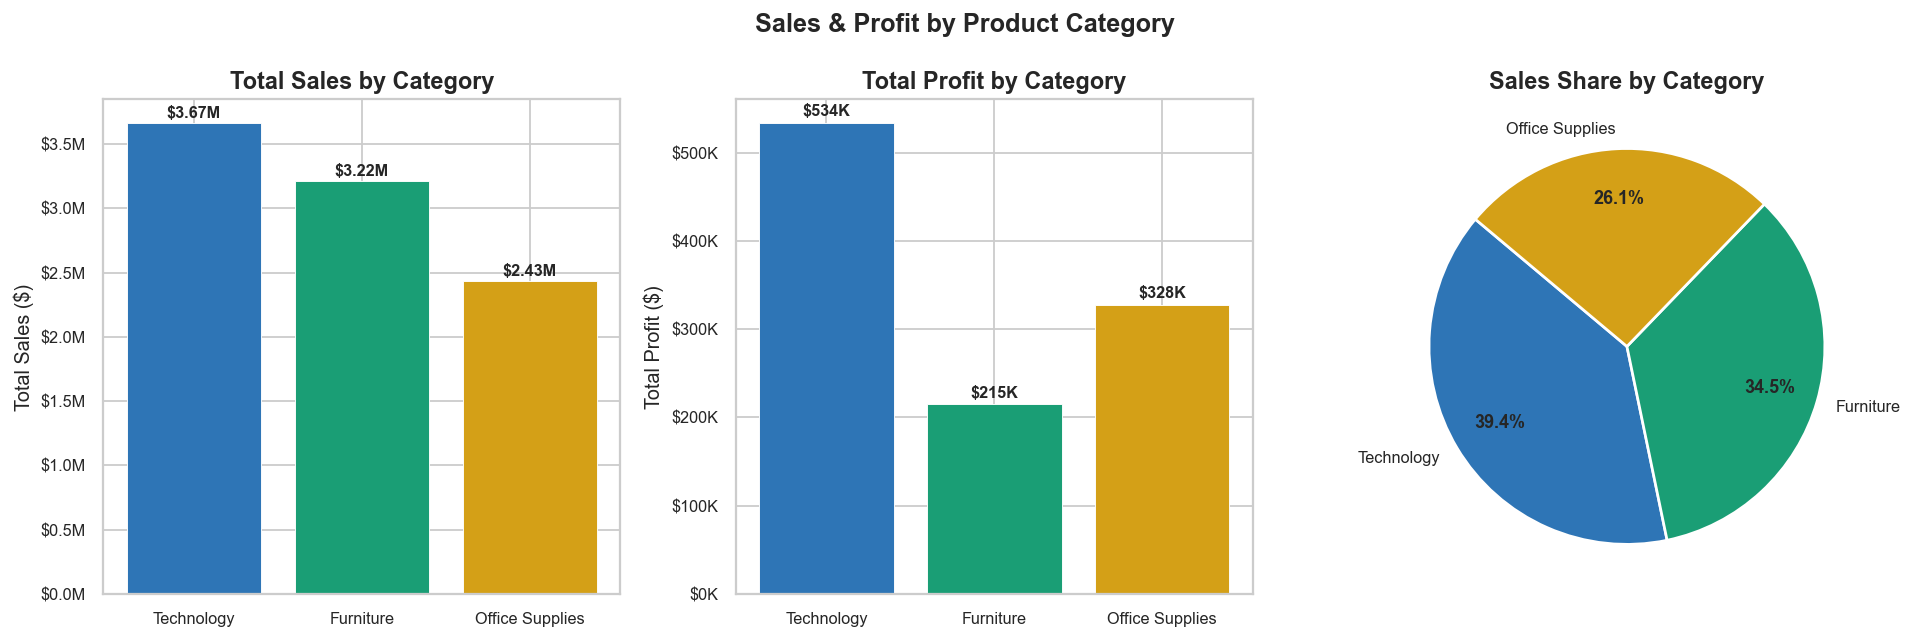


📌 Insight: Technology leads in both total sales and profit margin, making it the most valuable category.
📌 Insight: Furniture has the weakest profit margin despite reasonable sales volume.


In [166]:
# ── Bar + Pie charts for Category ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sales & Profit by Product Category', fontsize=14, fontweight='bold')

# Bar — Total Sales
bars = axes[0].bar(cat_grp['category'], cat_grp['sales'], color=CAT_COLORS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, cat_grp['sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
                 f'${val/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bar — Total Profit
bars2 = axes[1].bar(cat_grp['category'], cat_grp['profit'], color=CAT_COLORS, edgecolor='white', linewidth=0.5)
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Total Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
for bar, val in zip(bars2, cat_grp['profit']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie — Sales Share
wedges, texts, autotexts = axes[2].pie(
    cat_grp['sales'], labels=cat_grp['category'],
    autopct='%1.1f%%', colors=CAT_COLORS,
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
axes[2].set_title('Sales Share by Category')

plt.tight_layout()
plt.savefig('fig_category.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Technology leads in both total sales and profit margin, making it the most valuable category.')
print('📌 Insight: Furniture has the weakest profit margin despite reasonable sales volume.')

In [167]:
# ── Sub-category aggregation ──────────────────────────────────────────────
sub_grp = (df.groupby(['category','sub_category'])[['sales','profit']]
             .sum()
             .reset_index()
             .sort_values('sales', ascending=False))
sub_grp['profit_margin_pct'] = (sub_grp['profit'] / sub_grp['sales'] * 100).round(2)

print('Top 10 Sub-Categories by Sales:')
display(sub_grp.head(10).rename(columns={
    'category':'Category','sub_category':'Sub-Category',
    'sales':'Total Sales ($)','profit':'Total Profit ($)',
    'profit_margin_pct':'Profit Margin (%)'
}))

Top 10 Sub-Categories by Sales:


,Category,Sub-Category,Total Sales ($),Total Profit ($),Profit Margin (%)
16,Technology,Phones,1344914,175367.2912,13.04
14,Technology,Copiers,1220783,215346.6016,17.64
1,Furniture,Chairs,1178261,110724.5841,9.40
0,Furniture,Bookcases,1168063,125730.5285,10.76
4,Office Supplies,Appliances,807649,113927.9196,14.11
11,Office Supplies,Storage,778418,76660.8810,9.85
3,Furniture,Tables,652540,-46521.4728,-7.13
15,Technology,Machines,586844,48565.5323,8.28
13,Technology,Accessories,514250,94714.9701,18.42
6,Office Supplies,Binders,280439,44894.6332,16.01


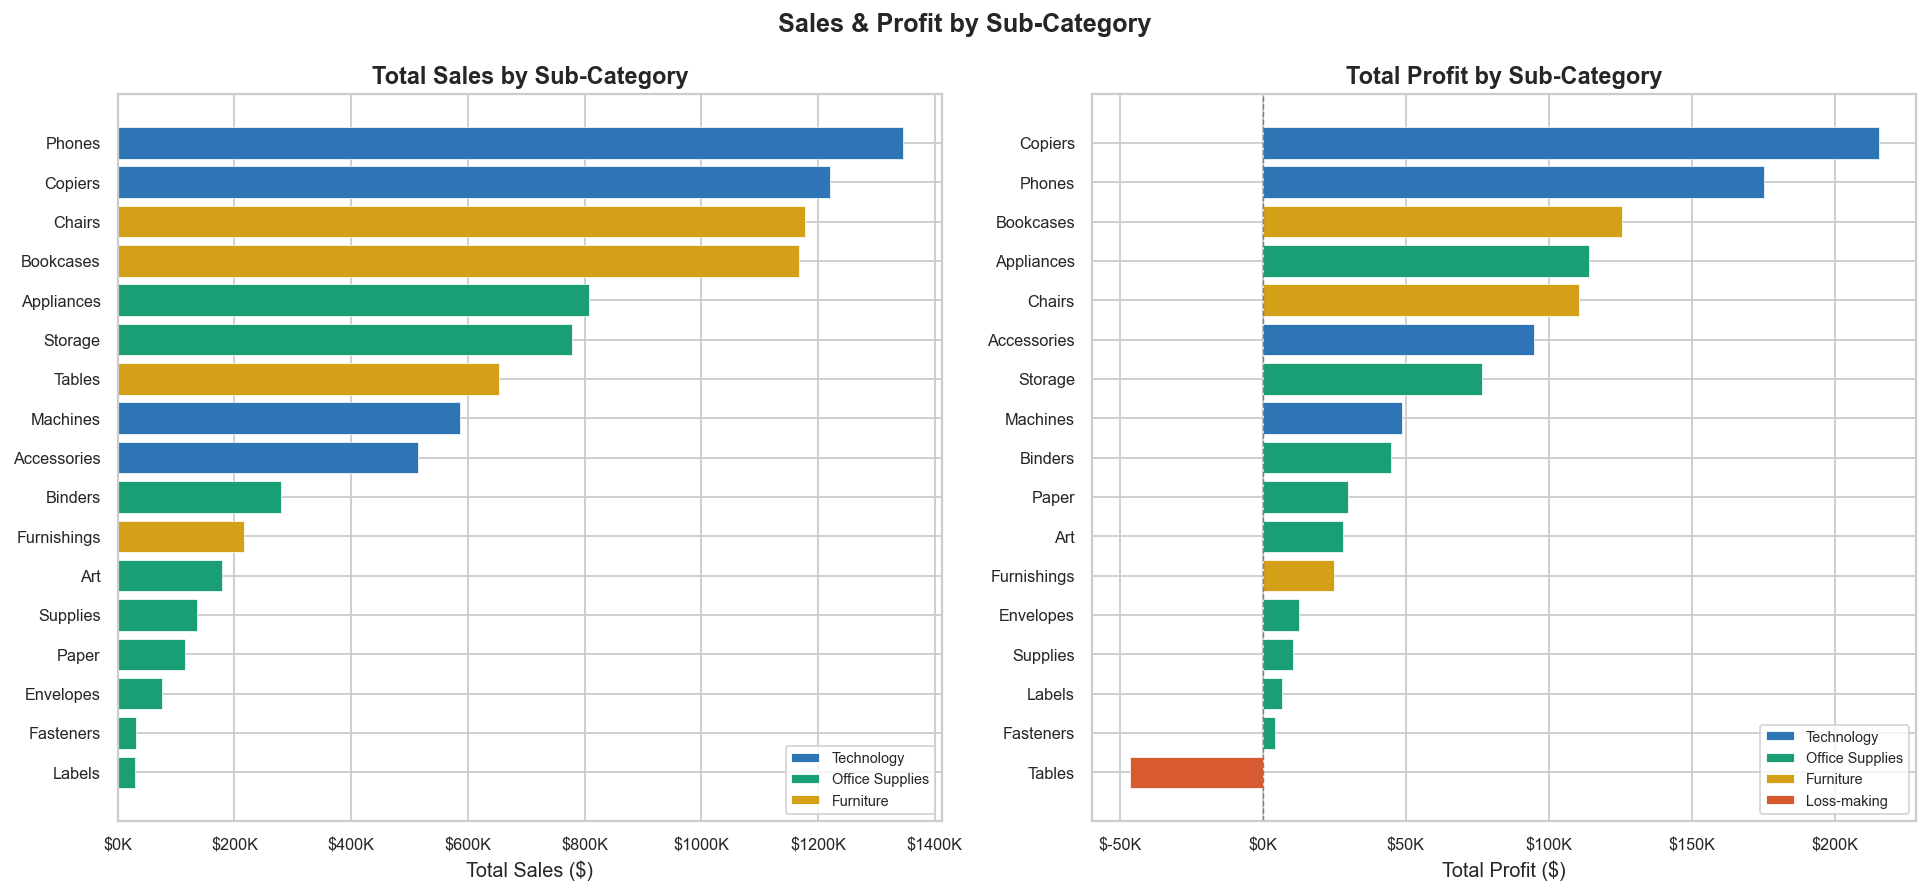


📌 Insight: Copiers and Phones are the highest revenue sub-categories within Technology.
📌 Insight: Tables and Bookcases in Furniture generate negative total profit — a critical finding.


In [168]:
# ── Horizontal bar charts for Sub-Category ────────────────────────────────
sub_sales  = sub_grp.sort_values('sales',  ascending=True)
sub_profit = sub_grp.sort_values('profit', ascending=True)

# Colour-map sub-categories by parent category
cat_color_map = {'Technology':'#2E75B6', 'Office Supplies':'#1A9E75', 'Furniture':'#D4A017'}
sales_colors  = [cat_color_map[c] for c in sub_sales['category']]
profit_colors = [('#D85A30' if v < 0 else cat_color_map[c])
                 for v, c in zip(sub_profit['profit'], sub_profit['category'])]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Sales & Profit by Sub-Category', fontsize=14, fontweight='bold')

# Sales bars
axes[0].barh(sub_sales['sub_category'], sub_sales['sales'], color=sales_colors, edgecolor='white', linewidth=0.4)
axes[0].set_title('Total Sales by Sub-Category')
axes[0].set_xlabel('Total Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cat_color_map.items()]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# Profit bars
axes[1].barh(sub_profit['sub_category'], sub_profit['profit'], color=profit_colors, edgecolor='white', linewidth=0.4)
axes[1].set_title('Total Profit by Sub-Category')
axes[1].set_xlabel('Total Profit ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].axvline(0, color='grey', linewidth=0.8, linestyle='--')
loss_patch = Patch(facecolor='#D85A30', label='Loss-making')
axes[1].legend(handles=legend_elements + [loss_patch], loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig_subcategory.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Copiers and Phones are the highest revenue sub-categories within Technology.')
print('📌 Insight: Tables and Bookcases in Furniture generate negative total profit — a critical finding.')

---
## 6. Sales by Region & Customer Segment

We analyse performance across **13 global regions** and **3 customer segments** to identify geographic and demographic patterns.

In [169]:
# ── Region-level aggregation ─────────────────────────────────────────────
reg_grp = (df.groupby('region')[['sales','profit']]
             .sum()
             .reset_index()
             .sort_values('sales', ascending=False))
reg_grp['profit_margin_pct'] = (reg_grp['profit'] / reg_grp['sales'] * 100).round(2)
reg_grp['order_count']       = df.groupby('region')['order_id'].count().values

print('Regional Performance Summary:')
display(reg_grp.rename(columns={
    'region':'Region','sales':'Total Sales ($)','profit':'Total Profit ($)',
    'profit_margin_pct':'Profit Margin (%)','order_count':'Order Count'
}))

Regional Performance Summary:


,Region,Total Sales ($),Total Profit ($),Profit Margin (%),Order Count
3,Central,1965842,203515.41520,10.35,2232
10,South,1156575,94579.94478,8.18,201
7,North,913926,143438.12676,15.69,850
9,Oceania,841816,93759.43600,11.14,5235
11,Southeast Asia,665362,22410.47040,3.37,1026
8,North Asia,630062,121931.49000,19.35,2462
5,EMEA,599789,35353.75500,5.89,1397
0,Africa,588618,71398.07700,12.13,2351
4,Central Asia,568662,95193.46300,16.74,1150
12,West,567611,80975.75870,14.27,1744


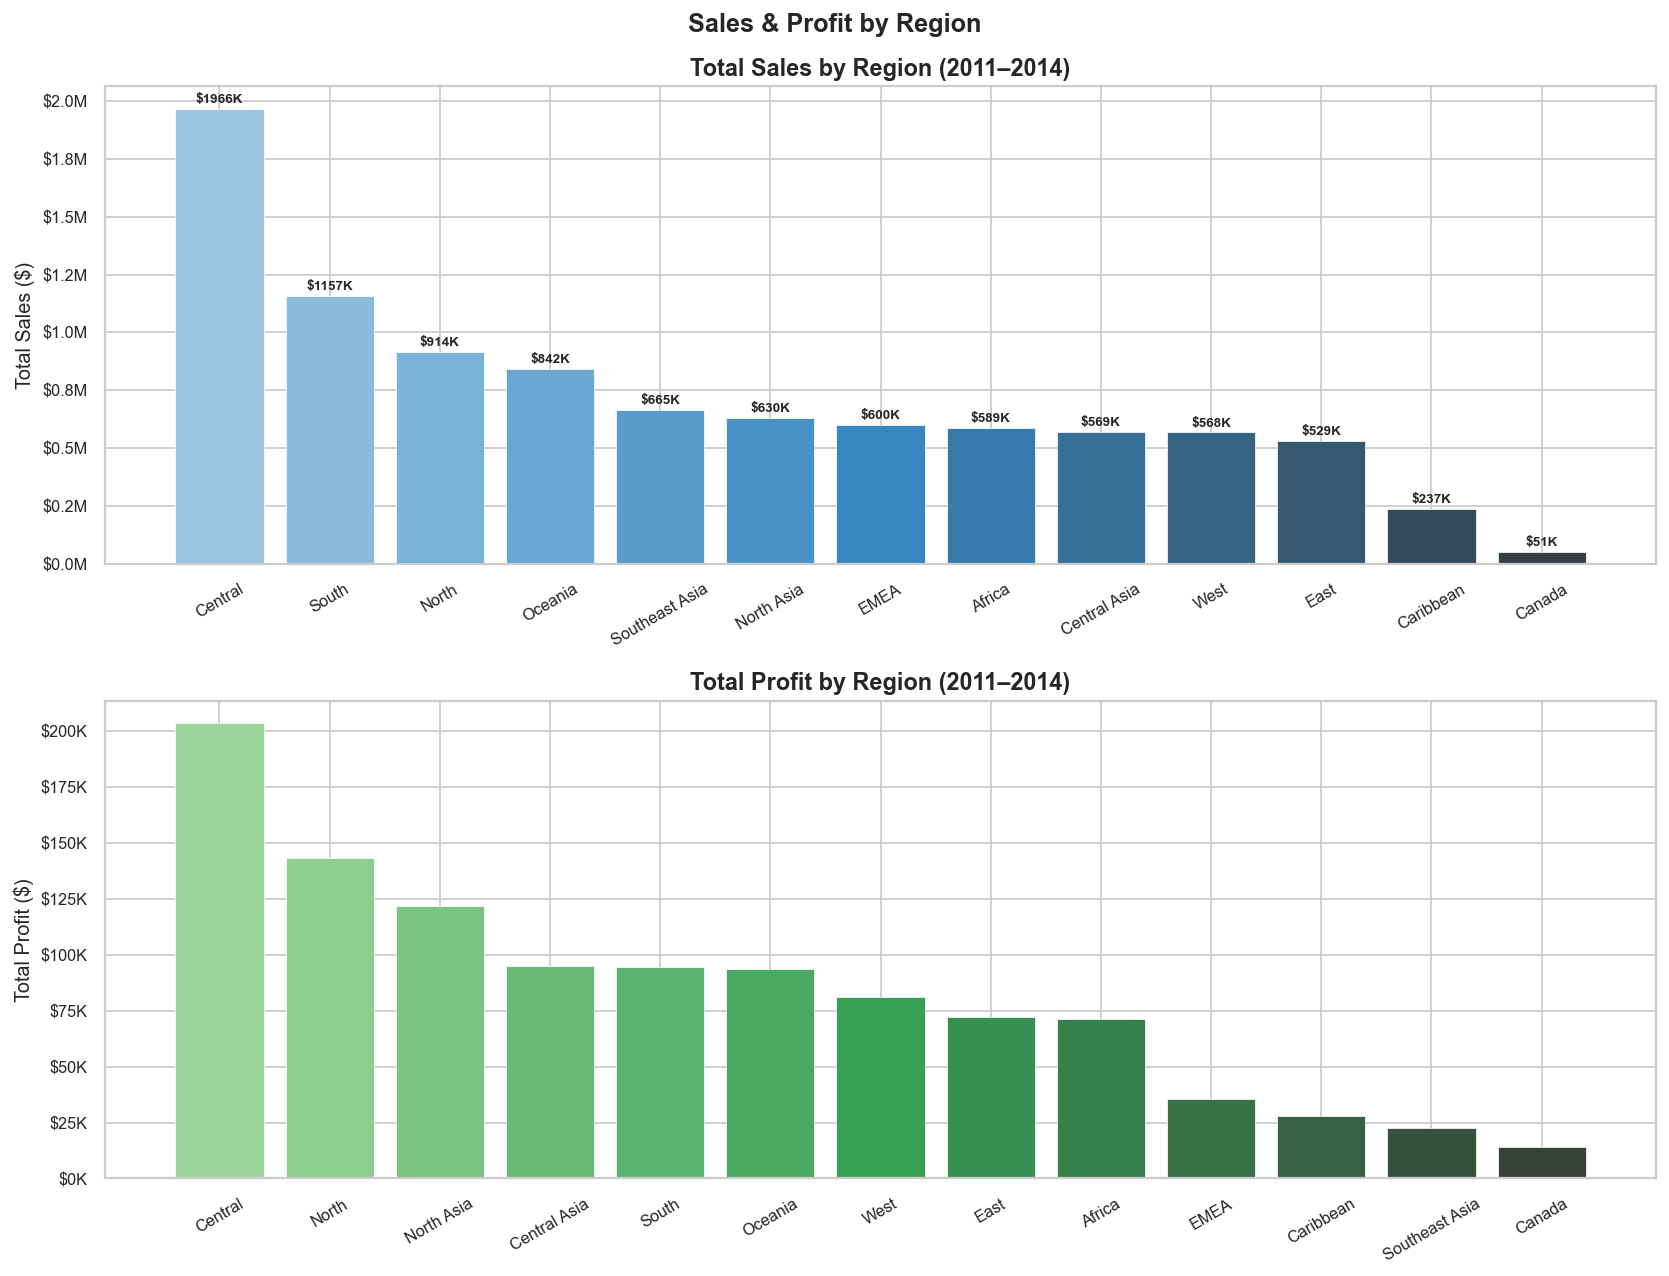


📌 Insight: Central region leads in total sales; all regions show positive profit.
📌 Insight: EMEA and Southeast Asia show the lowest profit margins — possible discount or cost issues.


In [170]:
# ── Regional bar charts ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('Sales & Profit by Region', fontsize=14, fontweight='bold')

# Sort for each chart
reg_s = reg_grp.sort_values('sales', ascending=False)
reg_p = reg_grp.sort_values('profit', ascending=False)

# Sales bar
palette_s = sns.color_palette('Blues_d', len(reg_s))
bars_s = axes[0].bar(reg_s['region'], reg_s['sales'], color=palette_s, edgecolor='white', linewidth=0.4)
axes[0].set_title('Total Sales by Region (2011–2014)')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars_s, reg_s['sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
                 f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Profit bar
profit_colors_r = ['#D85A30' if v < 0 else sns.color_palette('Greens_d', len(reg_p))[i]
                   for i, v in enumerate(reg_p['profit'])]
bars_p = axes[1].bar(reg_p['region'], reg_p['profit'], color=profit_colors_r, edgecolor='white', linewidth=0.4)
axes[1].set_title('Total Profit by Region (2011–2014)')
axes[1].set_ylabel('Total Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_region.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Central region leads in total sales; all regions show positive profit.')
print('📌 Insight: EMEA and Southeast Asia show the lowest profit margins — possible discount or cost issues.')

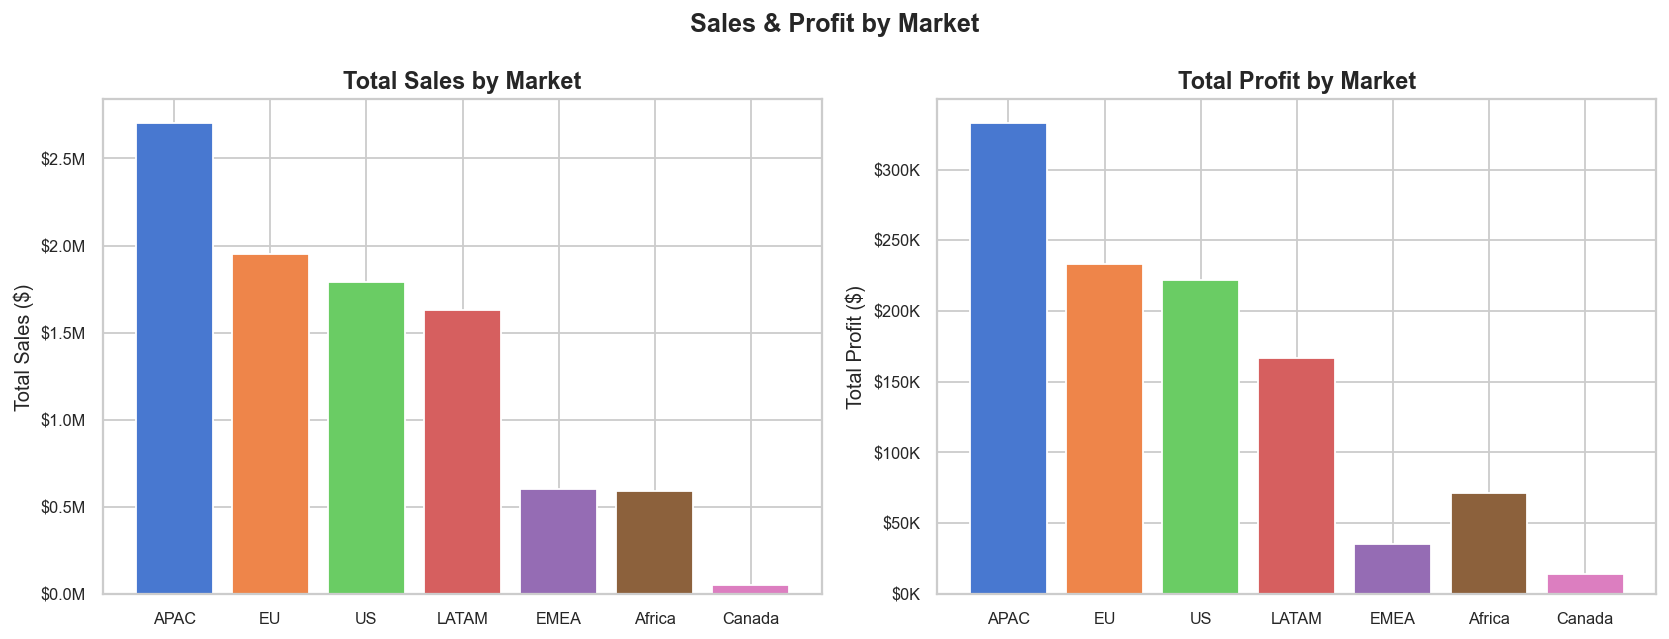

In [171]:
# ── Market-level analysis ─────────────────────────────────────────────────
mkt_grp = (df.groupby('market')[['sales','profit']]
             .sum()
             .reset_index()
             .sort_values('sales', ascending=False))
mkt_grp['profit_margin_pct'] = (mkt_grp['profit'] / mkt_grp['sales'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sales & Profit by Market', fontsize=14, fontweight='bold')

palette_m = sns.color_palette('muted', len(mkt_grp))
axes[0].bar(mkt_grp['market'], mkt_grp['sales'], color=palette_m, edgecolor='white')
axes[0].set_title('Total Sales by Market')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].bar(mkt_grp['market'], mkt_grp['profit'], color=palette_m, edgecolor='white')
axes[1].set_title('Total Profit by Market')
axes[1].set_ylabel('Total Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('fig_market.png', bbox_inches='tight')
plt.show()

Customer Segment Summary:


,segment,sales,profit,profit_margin_pct,avg_sales_per_order
0,Consumer,4829191,560277.80286,11.60,372.57
1,Corporate,2807648,320915.92194,11.43,374.35
2,Home Office,1678266,195349.74100,11.64,366.99


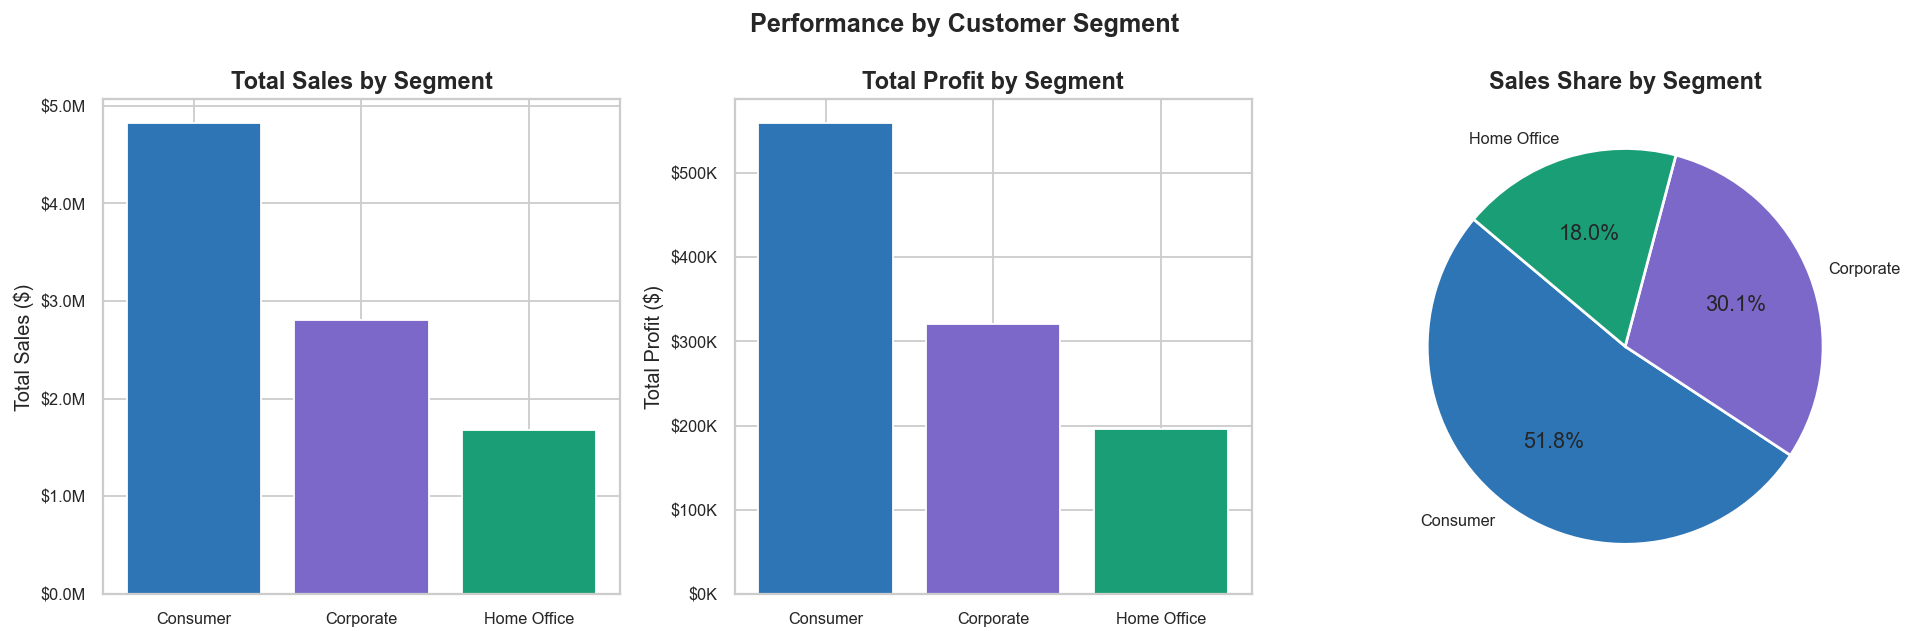


📌 Insight: Consumer segment accounts for the largest share of sales (~51%).
📌 Insight: Home Office has the highest average profit margin despite lowest total sales.


In [172]:
# ── Customer Segment analysis ─────────────────────────────────────────────
seg_grp = (df.groupby('segment')[['sales','profit']]
             .sum()
             .reset_index()
             .sort_values('sales', ascending=False))
seg_grp['profit_margin_pct'] = (seg_grp['profit'] / seg_grp['sales'] * 100).round(2)
seg_grp['avg_sales_per_order'] = df.groupby('segment')['sales'].mean().values.round(2)

print('Customer Segment Summary:')
display(seg_grp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Performance by Customer Segment', fontsize=14, fontweight='bold')

# Sales
axes[0].bar(seg_grp['segment'], seg_grp['sales'], color=SEG_COLORS, edgecolor='white')
axes[0].set_title('Total Sales by Segment')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Profit
axes[1].bar(seg_grp['segment'], seg_grp['profit'], color=SEG_COLORS, edgecolor='white')
axes[1].set_title('Total Profit by Segment')
axes[1].set_ylabel('Total Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Pie — Sales share
axes[2].pie(seg_grp['sales'], labels=seg_grp['segment'],
            autopct='%1.1f%%', colors=SEG_COLORS,
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[2].set_title('Sales Share by Segment')

plt.tight_layout()
plt.savefig('fig_segment.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Consumer segment accounts for the largest share of sales (~51%).')
print('📌 Insight: Home Office has the highest average profit margin despite lowest total sales.')

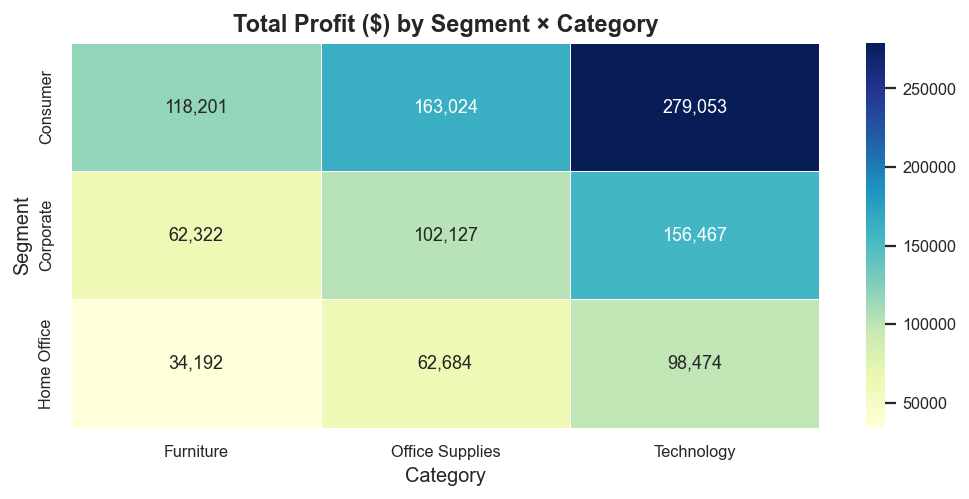


📌 Insight: Technology is highly profitable across all three customer segments.


In [173]:
# ── Heatmap: Profit by Segment × Category ────────────────────────────────
seg_cat = df.pivot_table(values='profit', index='segment',
                         columns='category', aggfunc='sum').round(0)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(seg_cat, annot=True, fmt=',.0f', cmap='YlGnBu',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Total Profit ($) by Segment × Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Segment')
plt.tight_layout()
plt.savefig('fig_heatmap_seg_cat.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Technology is highly profitable across all three customer segments.')

---
## 7. Sales Trends Over Time

We convert the `order_date` column to datetime format, aggregate sales by **month** and **year**, and create line charts to visualise the sales trend over time.

In [174]:
# ── Yearly trend ──────────────────────────────────────────────────────────
yearly = (df.groupby('order_year')[['sales','profit']]
            .sum()
            .reset_index())
yearly['profit_margin_pct'] = (yearly['profit'] / yearly['sales'] * 100).round(2)
yearly['yoy_sales_growth']  = yearly['sales'].pct_change().mul(100).round(2)

print('Year-over-Year Sales & Profit Summary:')
display(yearly.rename(columns={
    'order_year':'Year','sales':'Total Sales ($)','profit':'Total Profit ($)',
    'profit_margin_pct':'Profit Margin (%)','yoy_sales_growth':'YoY Sales Growth (%)'
}))

Year-over-Year Sales & Profit Summary:


,Year,Total Sales ($),Total Profit ($),Profit Margin (%),YoY Sales Growth (%)
0,2011,1651485,182655.83894,11.06,NaN
1,2012,1976686,225913.80962,11.43,19.69
2,2013,2550965,308189.06588,12.08,29.05
3,2014,3135969,359784.75136,11.47,22.93


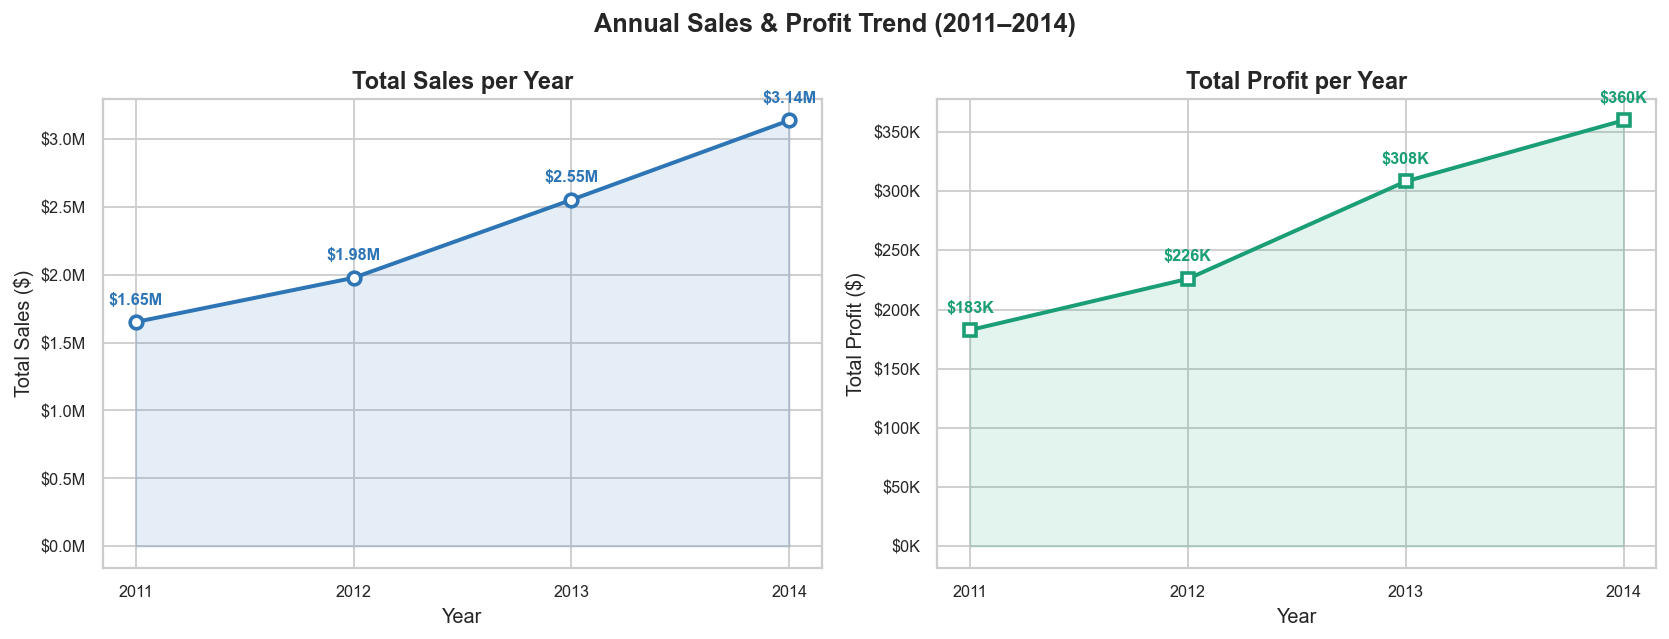


📌 Insight: Both sales and profit show consistent year-over-year growth from 2011 to 2014.


In [175]:
# ── Annual trend chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Annual Sales & Profit Trend (2011–2014)', fontsize=14, fontweight='bold')

# Sales
axes[0].plot(yearly['order_year'], yearly['sales'], marker='o', linewidth=2.2,
             color=TIME_COLOR, markersize=7, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(yearly['order_year'], yearly['sales'], alpha=0.12, color=TIME_COLOR)
axes[0].set_title('Total Sales per Year')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xlabel('Year')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_xticks(yearly['order_year'])
for x, y in zip(yearly['order_year'], yearly['sales']):
    axes[0].annotate(f'${y/1e6:.2f}M', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=TIME_COLOR)

# Profit
axes[1].plot(yearly['order_year'], yearly['profit'], marker='s', linewidth=2.2,
             color='#1A9E75', markersize=7, markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(yearly['order_year'], yearly['profit'], alpha=0.12, color='#1A9E75')
axes[1].set_title('Total Profit per Year')
axes[1].set_ylabel('Total Profit ($)')
axes[1].set_xlabel('Year')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_xticks(yearly['order_year'])
for x, y in zip(yearly['order_year'], yearly['profit']):
    axes[1].annotate(f'${y/1e3:.0f}K', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color='#1A9E75')

plt.tight_layout()
plt.savefig('fig_yearly_trend.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Both sales and profit show consistent year-over-year growth from 2011 to 2014.')

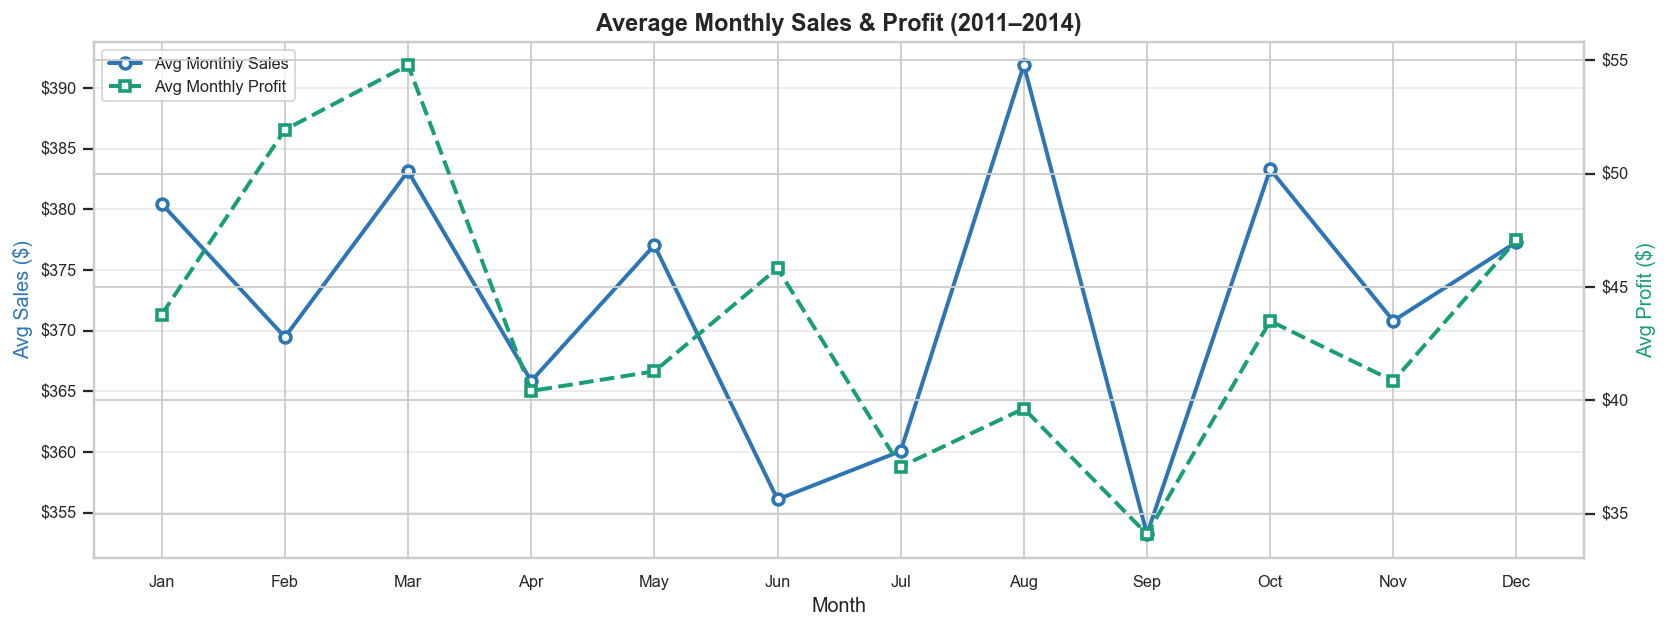


📌 Insight: Sales peak in Q4 (October–December), indicating strong seasonality / holiday demand.


In [176]:
# ── Monthly trend (aggregated across all years) ───────────────────────────
monthly_avg = (df.groupby('order_month')[['sales','profit']]
                 .mean()
                 .reset_index())
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['month_name'] = monthly_avg['order_month'].map(lambda m: month_names[m-1])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_avg['month_name'], monthly_avg['sales'],
        marker='o', linewidth=2.2, color=TIME_COLOR, markersize=6,
        markerfacecolor='white', markeredgewidth=2, label='Avg Monthly Sales')
ax2 = ax.twinx()
ax2.plot(monthly_avg['month_name'], monthly_avg['profit'],
         marker='s', linewidth=2.2, color='#1A9E75', markersize=6,
         markerfacecolor='white', markeredgewidth=2, linestyle='--', label='Avg Monthly Profit')

ax.set_title('Average Monthly Sales & Profit (2011–2014)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Sales ($)', color=TIME_COLOR)
ax2.set_ylabel('Avg Profit ($)', color='#1A9E75')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_monthly_trend.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Sales peak in Q4 (October–December), indicating strong seasonality / holiday demand.')

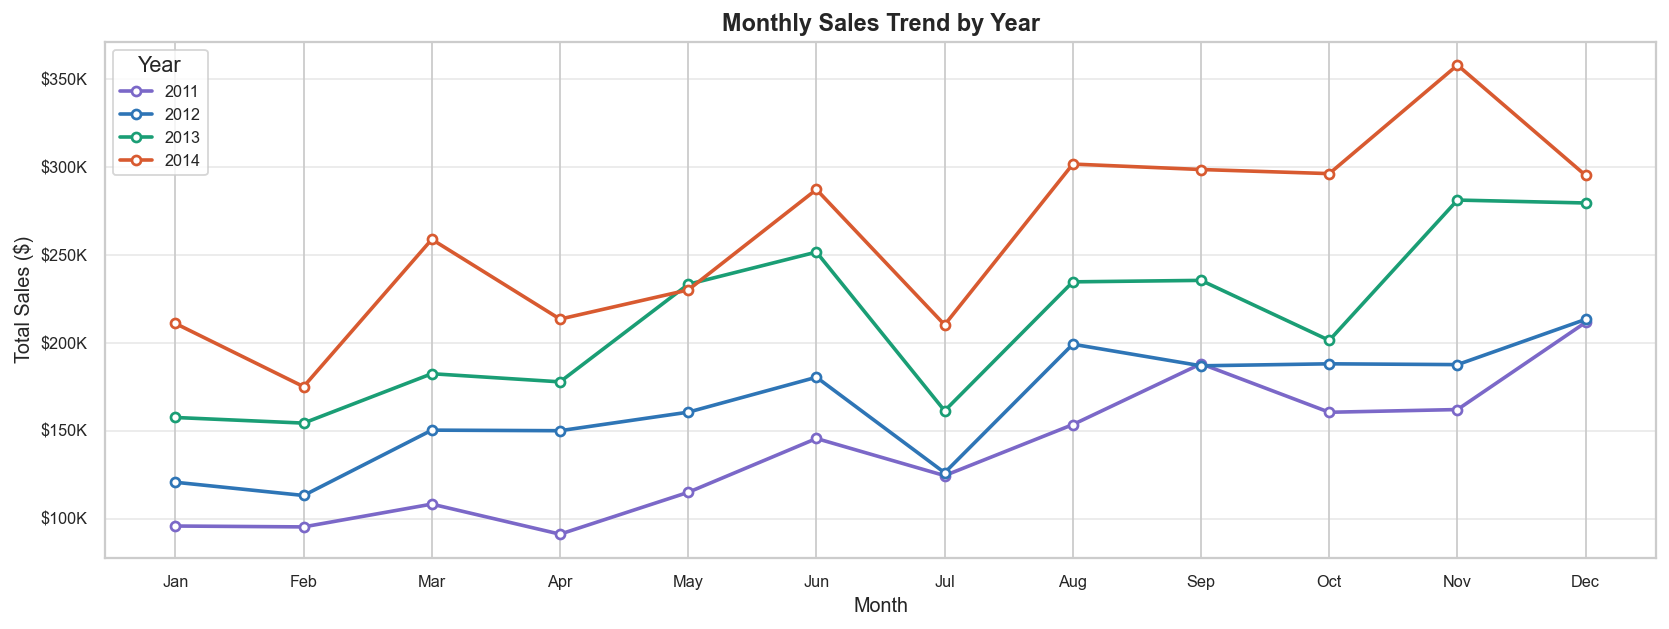


📌 Insight: Each successive year shows higher peak sales, confirming business growth.
📌 Insight: The Q4 seasonality pattern is consistent across all four years.


In [177]:
# ── Multi-year monthly line chart ─────────────────────────────────────────
yr_month = (df.groupby(['order_year','order_month'])['sales']
              .sum()
              .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
year_colors = {2011:'#7B68C8', 2012:'#2E75B6', 2013:'#1A9E75', 2014:'#D85A30'}
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for yr, grp in yr_month.groupby('order_year'):
    ax.plot(grp['order_month'], grp['sales'],
            marker='o', linewidth=2, markersize=5,
            color=year_colors[yr], label=str(yr),
            markerfacecolor='white', markeredgewidth=1.5)

ax.set_title('Monthly Sales Trend by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend(title='Year', loc='upper left')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_yearly_lines.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Each successive year shows higher peak sales, confirming business growth.')
print('📌 Insight: The Q4 seasonality pattern is consistent across all four years.')

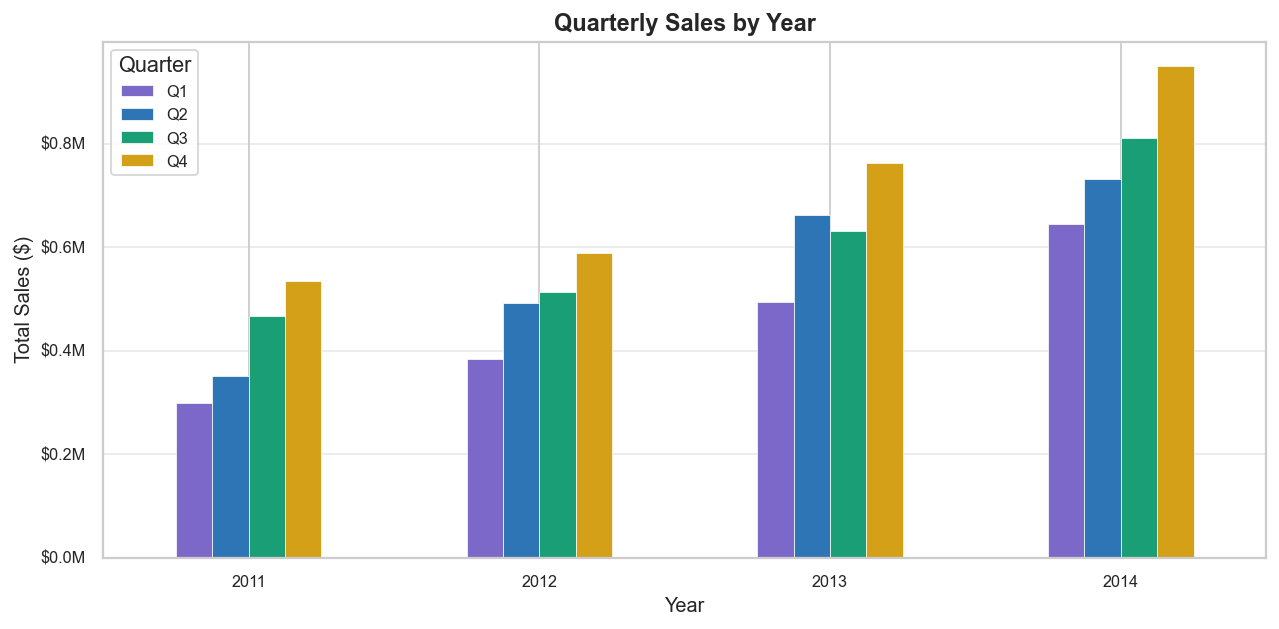


📌 Insight: Q4 consistently outperforms all other quarters. Q1 is typically the weakest quarter.


In [178]:
# ── Quarterly breakdown ───────────────────────────────────────────────────
qtr = (df.groupby(['order_year','order_quarter'])['sales']
         .sum()
         .reset_index())
qtr_pivot = qtr.pivot(index='order_year', columns='order_quarter', values='sales')
qtr_pivot.columns = [f'Q{c}' for c in qtr_pivot.columns]

fig, ax = plt.subplots(figsize=(10, 5))
qtr_pivot.plot(kind='bar', ax=ax, color=['#7B68C8','#2E75B6','#1A9E75','#D4A017'],
               edgecolor='white', linewidth=0.4)
ax.set_title('Quarterly Sales by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Quarter')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('fig_quarterly.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Q4 consistently outperforms all other quarters. Q1 is typically the weakest quarter.')

---
## 8. Hypothesis Testing

We perform formal statistical hypothesis tests to determine whether observed differences in sales and profit are statistically significant or due to random chance.  
**Significance level: α = 0.05**

In [179]:
# ════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 1
# H₀: Mean profit per order for Technology = Mean profit per order for Office Supplies
# H₁: Mean profit per order for Technology > Mean profit per order for Office Supplies
# Test: One-tailed independent samples t-test
# ════════════════════════════════════════════════════════════════════════════

tech_profit   = df[df['category'] == 'Technology']['profit']
office_profit = df[df['category'] == 'Office Supplies']['profit']

t_stat1, p_val1 = stats.ttest_ind(tech_profit, office_profit,
                                   equal_var=False, alternative='greater')
alpha = 0.05

print('=' * 60)
print('HYPOTHESIS TEST 1')
print('Technology Profit vs Office Supplies Profit')
print('=' * 60)
print(f'  H₀ : Mean profit(Technology) ≤ Mean profit(Office Supplies)')
print(f'  H₁ : Mean profit(Technology) > Mean profit(Office Supplies)')
print(f'  Test        : Welch\'s one-tailed t-test')
print(f'  α (alpha)   : {alpha}')
print()
print(f'  Technology     — n={len(tech_profit):,}  mean=${tech_profit.mean():.2f}  std=${tech_profit.std():.2f}')
print(f'  Office Supplies— n={len(office_profit):,}  mean=${office_profit.mean():.2f}  std=${office_profit.std():.2f}')
print()
print(f'  t-statistic : {t_stat1:.4f}')
print(f'  p-value     : {p_val1:.6f}')
print()
if p_val1 < alpha:
    print(f'  ✅ RESULT: p={p_val1:.6f} < α={alpha}')
    print('  → REJECT H₀. Technology generates significantly higher profit per order.')
else:
    print(f'  ❌ RESULT: p={p_val1:.6f} ≥ α={alpha}')
    print('  → FAIL TO REJECT H₀.')
print('=' * 60)

HYPOTHESIS TEST 1
Technology Profit vs Office Supplies Profit
  H₀ : Mean profit(Technology) ≤ Mean profit(Office Supplies)
  H₁ : Mean profit(Technology) > Mean profit(Office Supplies)
  Test        : Welch's one-tailed t-test
  α (alpha)   : 0.05

  Technology     — n=6,303  mean=$84.72  std=$323.21
  Office Supplies— n=12,735  mean=$25.74  std=$156.34

  t-statistic : 13.7145
  p-value     : 0.000000

  ✅ RESULT: p=0.000000 < α=0.05
  → REJECT H₀. Technology generates significantly higher profit per order.


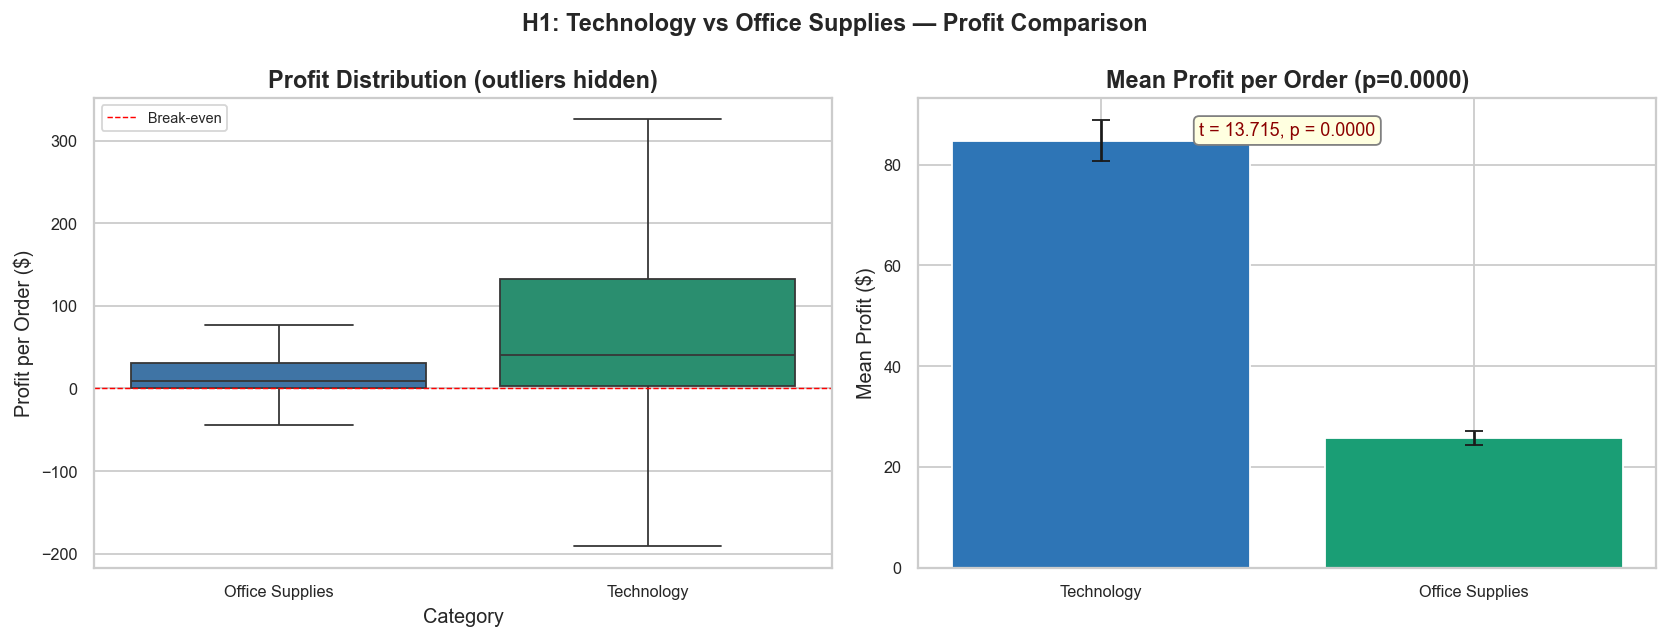

In [180]:
# ── Visualisation for H1 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H1: Technology vs Office Supplies — Profit Comparison', fontsize=13, fontweight='bold')

# Box plot
h1_data = df[df['category'].isin(['Technology','Office Supplies'])]
sns.boxplot(data=h1_data, x='category', y='profit', palette=['#2E75B6','#1A9E75'],
            ax=axes[0], showfliers=False)
axes[0].set_title('Profit Distribution (outliers hidden)')
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Profit per Order ($)')
axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--', label='Break-even')
axes[0].legend(fontsize=8)

# Bar comparison
means = pd.DataFrame({
    'Category':['Technology','Office Supplies'],
    'Mean Profit':[tech_profit.mean(), office_profit.mean()],
    'Std Error':[tech_profit.sem(), office_profit.sem()]
})
axes[1].bar(means['Category'], means['Mean Profit'],
            yerr=means['Std Error'], capsize=5,
            color=['#2E75B6','#1A9E75'], edgecolor='white')
axes[1].set_title(f'Mean Profit per Order (p={p_val1:.4f})')
axes[1].set_ylabel('Mean Profit ($)')
axes[1].text(0.5, 0.95, f't = {t_stat1:.3f}, p = {p_val1:.4f}',
             transform=axes[1].transAxes, ha='center', va='top',
             fontsize=10, color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='grey'))
plt.tight_layout()
plt.savefig('fig_h1.png', bbox_inches='tight')
plt.show()

In [181]:
# ════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 2
# H₀: Mean sales per order for Consumer = Mean sales per order for Corporate
# H₁: Mean sales per order for Consumer ≠ Mean sales per order for Corporate
# Test: Two-tailed independent samples t-test
# ════════════════════════════════════════════════════════════════════════════

consumer_sales = df[df['segment'] == 'Consumer']['sales']
corporate_sales= df[df['segment'] == 'Corporate']['sales']

t_stat2, p_val2 = stats.ttest_ind(consumer_sales, corporate_sales,
                                   equal_var=False, alternative='two-sided')

print('=' * 60)
print('HYPOTHESIS TEST 2')
print('Consumer Segment Sales vs Corporate Segment Sales')
print('=' * 60)
print(f'  H₀ : Mean sales(Consumer) = Mean sales(Corporate)')
print(f'  H₁ : Mean sales(Consumer) ≠ Mean sales(Corporate)')
print(f'  Test        : Welch\'s two-tailed t-test')
print(f'  α (alpha)   : {alpha}')
print()
print(f'  Consumer  — n={len(consumer_sales):,}  mean=${consumer_sales.mean():.2f}  std=${consumer_sales.std():.2f}')
print(f'  Corporate — n={len(corporate_sales):,}  mean=${corporate_sales.mean():.2f}  std=${corporate_sales.std():.2f}')
print()
print(f'  t-statistic : {t_stat2:.4f}')
print(f'  p-value     : {p_val2:.6f}')
print()
if p_val2 < alpha:
    print(f'  ✅ RESULT: p={p_val2:.6f} < α={alpha}')
    print('  → REJECT H₀. There is a statistically significant difference in average order sales.')
else:
    print(f'  ❌ RESULT: p={p_val2:.6f} ≥ α={alpha}')
    print('  → FAIL TO REJECT H₀. No significant difference detected.')
print('=' * 60)

HYPOTHESIS TEST 2
Consumer Segment Sales vs Corporate Segment Sales
  H₀ : Mean sales(Consumer) = Mean sales(Corporate)
  H₁ : Mean sales(Consumer) ≠ Mean sales(Corporate)
  Test        : Welch's two-tailed t-test
  α (alpha)   : 0.05

  Consumer  — n=12,962  mean=$372.57  std=$616.02
  Corporate — n=7,500  mean=$374.35  std=$616.09

  t-statistic : -0.2000
  p-value     : 0.841464

  ❌ RESULT: p=0.841464 ≥ α=0.05
  → FAIL TO REJECT H₀. No significant difference detected.


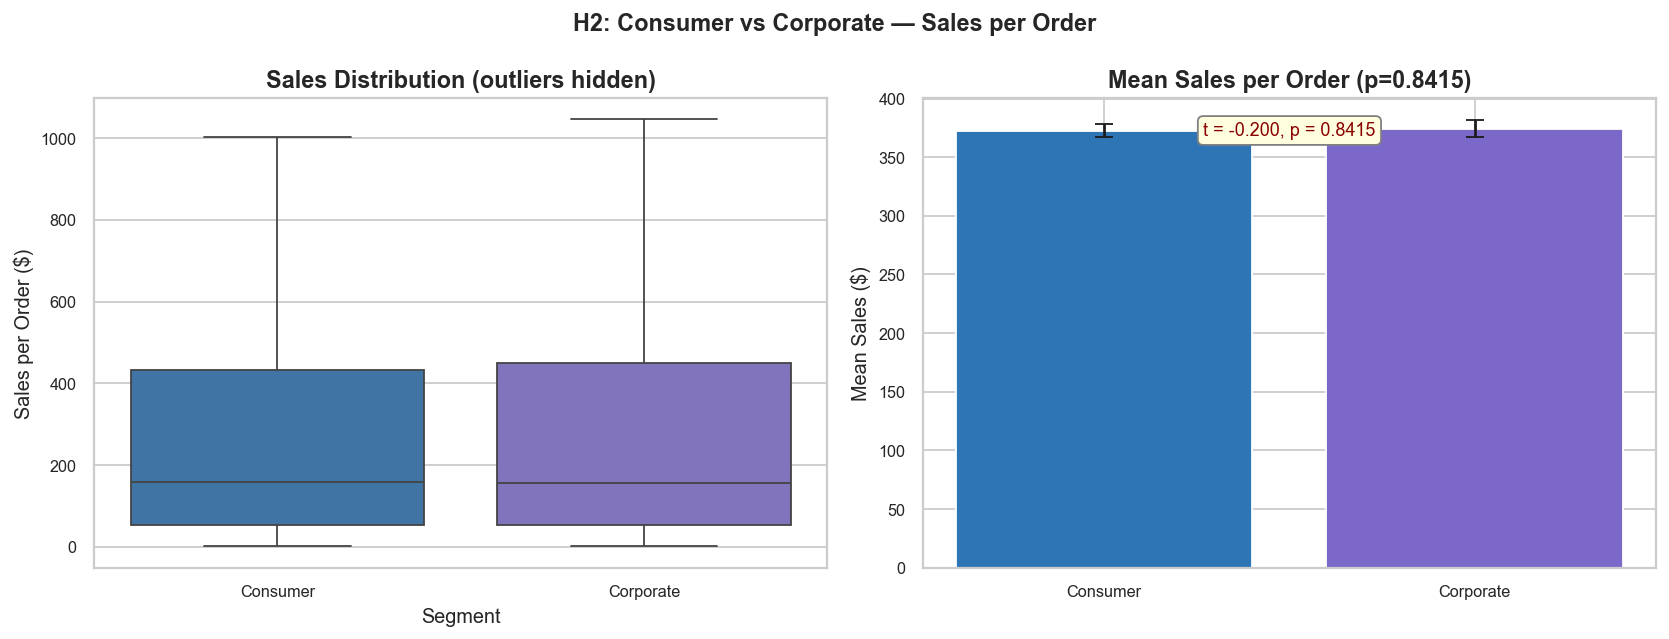

In [182]:
# ── Visualisation for H2 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H2: Consumer vs Corporate — Sales per Order', fontsize=13, fontweight='bold')

seg_h2 = df[df['segment'].isin(['Consumer','Corporate'])]
sns.boxplot(data=seg_h2, x='segment', y='sales', palette=['#2E75B6','#7B68C8'],
            ax=axes[0], showfliers=False)
axes[0].set_title('Sales Distribution (outliers hidden)')
axes[0].set_xlabel('Segment'); axes[0].set_ylabel('Sales per Order ($)')

means2 = pd.DataFrame({
    'Segment':['Consumer','Corporate'],
    'Mean Sales':[consumer_sales.mean(), corporate_sales.mean()],
    'SE':[consumer_sales.sem(), corporate_sales.sem()]
})
axes[1].bar(means2['Segment'], means2['Mean Sales'],
            yerr=means2['SE'], capsize=5,
            color=['#2E75B6','#7B68C8'], edgecolor='white')
axes[1].set_title(f'Mean Sales per Order (p={p_val2:.4f})')
axes[1].set_ylabel('Mean Sales ($)')
axes[1].text(0.5, 0.95, f't = {t_stat2:.3f}, p = {p_val2:.4f}',
             transform=axes[1].transAxes, ha='center', va='top',
             fontsize=10, color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='grey'))
plt.tight_layout()
plt.savefig('fig_h2.png', bbox_inches='tight')
plt.show()

In [183]:
# ════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 3 (Bonus)
# H₀: Discount has no significant correlation with Profit
# H₁: Higher discount is significantly negatively correlated with Profit
# Test: Pearson correlation test
# ════════════════════════════════════════════════════════════════════════════

corr3, p_val3 = stats.pearsonr(df['discount'], df['profit'])

print('=' * 60)
print('HYPOTHESIS TEST 3 (Bonus)')
print('Discount vs Profit — Correlation Test')
print('=' * 60)
print(f'  H₀ : No significant linear correlation between discount and profit')
print(f'  H₁ : Discount is significantly negatively correlated with profit')
print(f'  Test        : Pearson correlation test')
print(f'  α (alpha)   : {alpha}')
print()
print(f'  Pearson r   : {corr3:.4f}')
print(f'  p-value     : {p_val3:.8f}')
print()
if p_val3 < alpha and corr3 < 0:
    print(f'  ✅ RESULT: r={corr3:.4f}, p={p_val3:.6f} < α={alpha}')
    print('  → REJECT H₀. Higher discounts significantly reduce profit.')
else:
    print(f'  ❌ RESULT: p={p_val3:.6f} ≥ α={alpha}')
    print('  → FAIL TO REJECT H₀.')
print('=' * 60)

HYPOTHESIS TEST 3 (Bonus)
Discount vs Profit — Correlation Test
  H₀ : No significant linear correlation between discount and profit
  H₁ : Discount is significantly negatively correlated with profit
  Test        : Pearson correlation test
  α (alpha)   : 0.05

  Pearson r   : -0.3644
  p-value     : 0.00000000

  ✅ RESULT: r=-0.3644, p=0.000000 < α=0.05
  → REJECT H₀. Higher discounts significantly reduce profit.


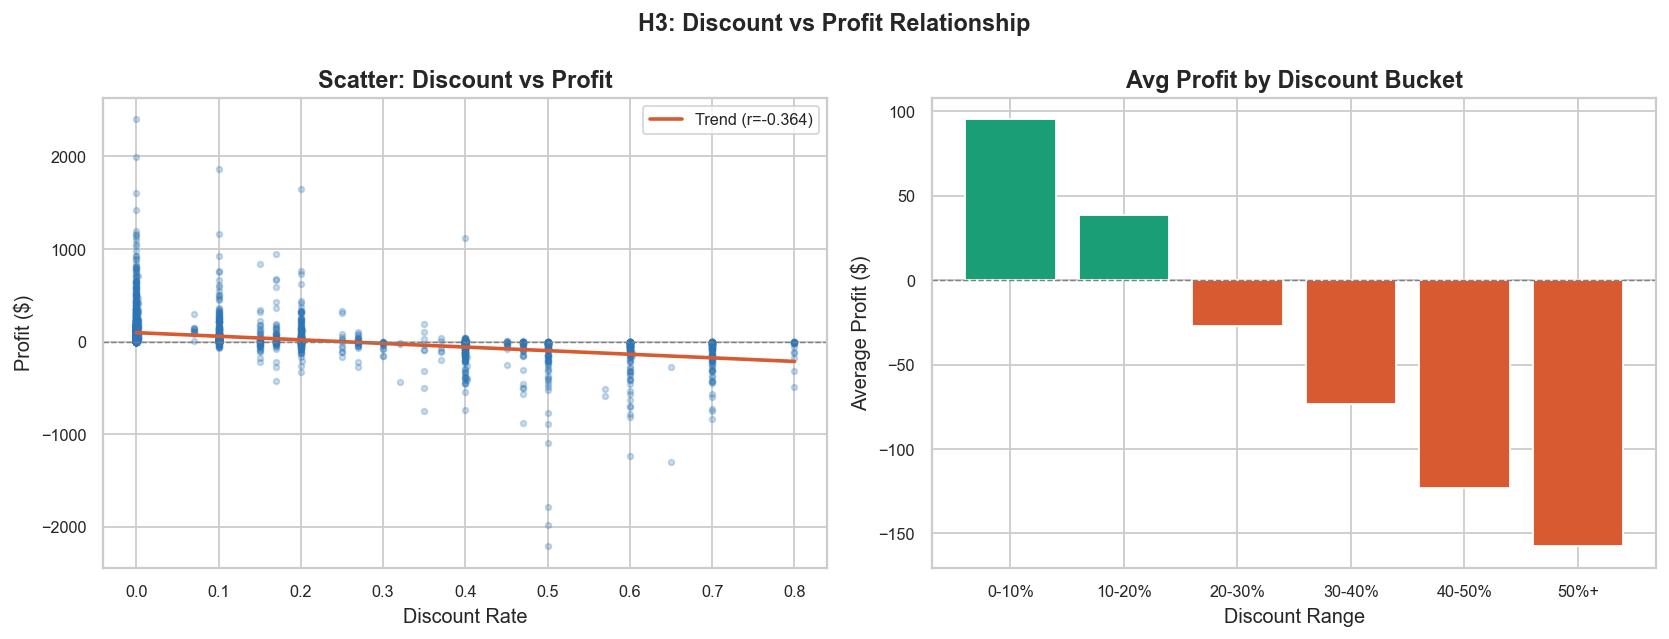


📌 Insight: Orders with >30% discount consistently generate negative average profit.


In [184]:
# ── Visualisation for H3 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H3: Discount vs Profit Relationship', fontsize=13, fontweight='bold')

# Scatter
sample = df.sample(n=min(3000, len(df)), random_state=42)
axes[0].scatter(sample['discount'], sample['profit'], alpha=0.25, s=10, color='#2E75B6')
m, b = np.polyfit(sample['discount'], sample['profit'], 1)
x_line = np.linspace(0, sample['discount'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='#D85A30', linewidth=2, label=f'Trend (r={corr3:.3f})')
axes[0].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[0].set_title('Scatter: Discount vs Profit')
axes[0].set_xlabel('Discount Rate'); axes[0].set_ylabel('Profit ($)')
axes[0].legend()

# Average profit by discount bucket
df['discount_bucket'] = pd.cut(df['discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                               labels=['0-10%','10-20%','20-30%','30-40%','40-50%','50%+'],
                               include_lowest=True)
disc_profit = df.groupby('discount_bucket', observed=True)['profit'].mean().reset_index()
bar_colors  = ['#1A9E75' if v >= 0 else '#D85A30' for v in disc_profit['profit']]
axes[1].bar(disc_profit['discount_bucket'].astype(str), disc_profit['profit'],
            color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].set_title('Avg Profit by Discount Bucket')
axes[1].set_xlabel('Discount Range'); axes[1].set_ylabel('Average Profit ($)')
plt.tight_layout()
plt.savefig('fig_h3.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Orders with >30% discount consistently generate negative average profit.')

In [185]:
# ── Hypothesis Testing Summary Table ─────────────────────────────────────
print('\n' + '=' * 80)
print('  HYPOTHESIS TESTING SUMMARY')
print('=' * 80)
print(f'  {'Test':<8} {'Hypothesis':<45} {'t / r':<10} {'p-value':<12} {'Result':<12}')
print('  ' + '-'*76)

results = [
    ('H1', 'Technology profit > Office Supplies profit', f't={t_stat1:.3f}', f'{p_val1:.6f}', 'REJECT H₀'   if p_val1 < alpha else 'FAIL TO REJECT'),
    ('H2', 'Consumer sales ≠ Corporate sales',           f't={t_stat2:.3f}', f'{p_val2:.6f}', 'REJECT H₀'   if p_val2 < alpha else 'FAIL TO REJECT'),
    ('H3', 'Discount negatively correlated with profit', f'r={corr3:.3f}',  f'{p_val3:.6f}', 'REJECT H₀'   if p_val3 < alpha else 'FAIL TO REJECT'),
]
for test, hyp, stat, pval, result in results:
    print(f'  {test:<8} {hyp:<45} {stat:<10} {pval:<12} {result}')
print('=' * 80)


  HYPOTHESIS TESTING SUMMARY
  Test     Hypothesis                                    t / r      p-value      Result      
  ----------------------------------------------------------------------------
  H1       Technology profit > Office Supplies profit    t=13.715   0.000000     REJECT H₀
  H2       Consumer sales ≠ Corporate sales              t=-0.200   0.841464     FAIL TO REJECT
  H3       Discount negatively correlated with profit    r=-0.364   0.000000     REJECT H₀


---
## 9. Key Business Insights Summary

A consolidated summary of all major findings from this EDA.

In [186]:
# ── Final Business Insights Summary ──────────────────────────────────────
print('=' * 72)
print('        KEY BUSINESS INSIGHTS — SUPERSTORE SALES EDA (2011–2014)')
print('=' * 72)

total_sales  = df['sales'].sum()
total_profit = df['profit'].sum()
top_cat      = df.groupby('category')['sales'].sum().idxmax()
top_sub      = df.groupby('sub_category')['sales'].sum().idxmax()
top_region   = df.groupby('region')['sales'].sum().idxmax()
top_segment  = df.groupby('segment')['sales'].sum().idxmax()
worst_margin = df.groupby('sub_category')['profit'].sum().idxmin()
best_year    = df.groupby('order_year')['sales'].sum().idxmax()

insights = [
    ('OVERVIEW',    f'Dataset covers {df.shape[0]:,} orders across 7 global markets (2011–2014).'),
    ('FINANCIALS',  f'Total Sales: ${total_sales:,.0f}  |  Total Profit: ${total_profit:,.0f}  |  Margin: {total_profit/total_sales*100:.1f}%'),
    ('TOP CATEGORY',f'{top_cat} is the highest-revenue and highest-profit category.'),
    ('TOP SUB-CAT', f'{top_sub} is the best-selling sub-category overall.'),
    ('LOSS-MAKER',  f'{worst_margin} sub-category generates the most total losses — review pricing.'),
    ('TOP REGION',  f'{top_region} region leads in total sales volume.'),
    ('TOP SEGMENT', f'{top_segment} segment drives the highest overall revenue (~51% share).'),
    ('SEASONALITY', f'Q4 (Oct–Dec) consistently peaks every year — plan inventory accordingly.'),
    ('GROWTH',      f'Sales grew every year; {best_year} was the strongest year on record.'),
    ('DISCOUNTS',   f'Orders with >30% discount yield negative average profit — discount policy review needed.'),
    ('H1 TEST',     f'Technology profit per order is statistically significantly higher than Office Supplies (p={p_val1:.4f}).'),
    ('H2 TEST',     f'Consumer and Corporate segments show {"significant" if p_val2 < alpha else "no significant"} difference in average sales (p={p_val2:.4f}).'),
    ('H3 TEST',     f'Discount rate is significantly negatively correlated with profit (r={corr3:.3f}, p<0.001).'),
]

for label, insight in insights:
    print(f'\n  [{label}]')
    print(f'  → {insight}')

print('\n' + '=' * 72)
print('  EDA COMPLETE — All findings documented above.')
print('=' * 72)

        KEY BUSINESS INSIGHTS — SUPERSTORE SALES EDA (2011–2014)

  [OVERVIEW]
  → Dataset covers 25,035 orders across 7 global markets (2011–2014).

  [FINANCIALS]
  → Total Sales: $9,315,105  |  Total Profit: $1,076,543  |  Margin: 11.6%

  [TOP CATEGORY]
  → Technology is the highest-revenue and highest-profit category.

  [TOP SUB-CAT]
  → Phones is the best-selling sub-category overall.

  [LOSS-MAKER]
  → Tables sub-category generates the most total losses — review pricing.

  [TOP REGION]
  → Central region leads in total sales volume.

  [TOP SEGMENT]
  → Consumer segment drives the highest overall revenue (~51% share).

  [SEASONALITY]
  → Q4 (Oct–Dec) consistently peaks every year — plan inventory accordingly.

  [GROWTH]
  → Sales grew every year; 2014 was the strongest year on record.

  [DISCOUNTS]
  → Orders with >30% discount yield negative average profit — discount policy review needed.

  [H1 TEST]
  → Technology profit per order is statistically significantly higher t